In [14]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister,ClassicalRegister, transpile

from IPython.display import Math
from qc_workbook.show_state import statevector_expr

import numpy as np
import matplotlib.pyplot as plt

from qiskit.visualization import plot_distribution

from qiskit_aer.primitives import SamplerV2 as Sampler

print("----Start----")
simulator = AerSimulator(method='statevector')
print(simulator.name)

----Start----
aer_simulator_statevector


In [15]:
def get_statevector_array(circuit):
    circuit = circuit.copy()
    circuit.save_statevector()
    circuit = transpile(circuit, backend=simulator)
    job = simulator.run(circuit)
    result = job.result()
    qiskit_statevector = result.data()['statevector']

    return np.asarray(qiskit_statevector)

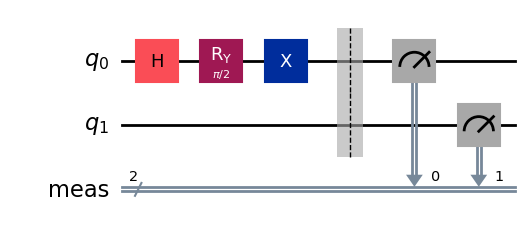

In [16]:
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.ry(np.pi/2., 0)
circuit.x(0)

circuit.measure_all()

circuit.draw('mpl')

In [17]:
sim = AerSimulator()

compiled_circuit = transpile(circuit, sim, optimization_level=0)

job = sim.run(compiled_circuit, shots=100) 
result = job.result()

counts = result.get_counts(compiled_circuit)
print(counts)

{'00': 100}
